## 1 Intro / Введение

### 1.1 Пять примеров применения машинного обучения (ML, модель) в жизни
1. **Фильтрация спама в почте.** Модель автоматически отделяет полезные письма от нежелательных и экономит время пользователя.
2. **Кредитный скоринг в банке.** Модель оценивает вероятность возврата кредита и помогает банку управлять финансовыми рисками.
3. **Анализ медицинских снимков.** Модель может находить подозрительные области на снимках и помогать врачу быстрее поставить диагноз.
4. **Рекомендательные системы.** Модель подбирает фильмы, музыку, рецепты блюд, товары или курсы под интересы пользователя.
5. **Прогнозирование спроса в магазинах.** Модель помогает заранее оценить будущие продажи и правильно планировать запасы.

### 1.2 Классы задач
#### Примеры из таблицы теории можно отнести к таким классам:  
- 1 Предсказать цену дома —> РЕГРЕССИЯ. Обучение с учителем  
- 2 Предсказать, вернёт ли клиент кредит —> Бинарная КЛАССИФИКАЦИЯ
- 3 Предсказать, когда пациенту нужно принять лекарство —> РЕГРЕССИЯ - количество времени, которое должно пройти с момента последнего приёма лекарства с учителем
- 4 Выбрать лекарство для пациента —> Многоклассовая КЛАССИФИКАЦИЯ или рекомендательная задача 
- 5 Выбрать сегмент клиентов для акции —> КЛАССИФИКАЦИЯ, (целевое значение, например, участвует ли клиент в акции или нет, покупает ли товары по акции или КЛАСТЕРИЗАЦИЯ - определение и предсказание поведения групп клиентов. Обучение без учителя.
- 6 Распознать дефект по фото —> Бинарная КЛАССИФИКАЦИЯ целевое значение - наличие или отсутствие дефекта
- 7 Решить, как расставить товары на полке —> Регрессия/оптимизация, иногда reinforcement learning 
- 8 Поиск сайтов по текстовому запросу —> РАНЖИРОВАНИЕ, цель — не предсказать абсолютное значение или категорию, а упорядочить (отсортировать) список объектов так, чтобы наиболее полезные, релевантные или интересные объекты оказались в самом верху списка, а наименее полезные — внизу
- 9 Разделить покупателей на сегменты —> Кластеризация. Обучение без учителя. 
- 10 Обнаружить аномалию в трафике сайта —> Поиск аномалий, обучение без учителя или с частичным привлечением учителя
#### Мои пять примеров:
- 1 Фильтрация спама —> бинарная классификация
- 2 Кредитный скоринг —> бинарная классификация или регрессия
- 3 Анализ медицинских снимков —> классификация или сегментация
- 4 Рекомендательные системы —> ранжирование, классификация, ассоциативные правила
- 5 Прогноз спроса —> регрессия, прогнозирование временных рядов


### 1.3 Multiclass и multilabel

В **многоклассовой классификации** объект относится ровно к одному классу из нескольких возможных. Например, фрукт может быть яблоком, грушей или бананом.

В **многометочной классификации** объект может иметь несколько меток одновременно. Например, фильм может быть и комедией, и мелодрамой.

### 1.4 Ответ на вопрос
#### Вопрос:
Является ли пример с ценами на дома из теории задачей классификации или регрессии? Можно ли свести задачу регрессии к классификации?
#### Ответ:
Пример с ценами на дома — это регрессия, потому что целевая переменная является непрерывным числом. Регрессию можно свести к классификации, если разбить цены на группы, например, дешёвые, средние и дорогие. Но при таком подходе теряется часть информации: точные цены заменяются категориями.

## 2 Введение в анализ данных

### Импорты библиотек, чтение датафрейма

In [1]:
%time
# Импортируем библиотеки для анализа данных, визуализации и обучения моделей.
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import scipy
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

import lightgbm as lgb

from ipywidgets import interact, IntSlider

warnings.filterwarnings("ignore") # Скрыть предупреждения
sns.set_theme(style="darkgrid", palette="Set2") # Сразу настроим фон и палитру для графиков
pd.set_option("display.max_columns", 100) # — чтобы пандас все столбцы показывал всегда (до сотни)
print('все библиотеки импортированы')

rs=21 # параметр для random state

CPU times: total: 0 ns
Wall time: 6.2 μs
все библиотеки импортированы


In [2]:
%time
DATA_PATH  = "data/train.json"
data = pd.read_json(DATA_PATH)
data.head()

CPU times: total: 0 ns
Wall time: 5.96 μs


,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium
6,1.0,2,b8e75fc949a6cd8225b455648a951712,2016-06-01 05:44:33,BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...,East 44th,"[Doorman, Elevator, Laundry in Building, Dishw...",40.7513,7092344,-73.9722,955db33477af4f40004820b4aed804a0,[https://photos.renthop.com/2/7092344_7663c19a...,3800,230 East 44th,low
9,1.0,2,cd759a988b8f23924b5a2058d5ab2b49,2016-06-14 15:19:59,**FLEX 2 BEDROOM WITH FULL PRESSURIZED WALL**L...,East 56th Street,"[Doorman, Elevator, Laundry in Building, Laund...",40.7575,7158677,-73.9625,c8b10a317b766204f08e613cef4ce7a0,[https://photos.renthop.com/2/7158677_c897a134...,3495,405 East 56th Street,medium
10,1.5,3,53a5b119ba8f7b61d4e010512e0dfc85,2016-06-24 07:54:24,A Brand New 3 Bedroom 1.5 bath ApartmentEnjoy ...,Metropolitan Avenue,[],40.7145,7211212,-73.9425,5ba989232d0489da1b5f2c45f6688adc,[https://photos.renthop.com/2/7211212_1ed4542e...,3000,792 Metropolitan Avenue,medium
15,1.0,0,bfb9405149bfff42a92980b594c28234,2016-06-28 03:50:23,Over-sized Studio w abundant closets. Availabl...,East 34th Street,"[Doorman, Elevator, Fitness Center, Laundry in...",40.7439,7225292,-73.9743,2c3b41f588fbb5234d8a1e885a436cfa,[https://photos.renthop.com/2/7225292_901f1984...,2795,340 East 34th Street,low


### Первичный анализ датафрейма

In [3]:
# Проверяем размер таблицы: количество строк и столбцов.
print(f"Размер датасета: {data.shape[0]} строк, {data.shape[1]} столбцов")

Размер датасета: 49352 строк, 15 столбцов


In [4]:
# Смотрим список столбцов и явно фиксируем целевую переменную.
print("Столбцы:")
print(data.columns.tolist())
print("\nЦелевая переменная: price")

Столбцы:
['bathrooms', 'bedrooms', 'building_id', 'created', 'description', 'display_address', 'features', 'latitude', 'listing_id', 'longitude', 'manager_id', 'photos', 'price', 'street_address', 'interest_level']

Целевая переменная: price


In [5]:
# Изучаем типы данных и количество непустых значений.
data.info()

<class 'pandas.DataFrame'>
Index: 49352 entries, 4 to 124009
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        49352 non-null  float64
 1   bedrooms         49352 non-null  int64  
 2   building_id      49352 non-null  str    
 3   created          49352 non-null  str    
 4   description      49352 non-null  str    
 5   display_address  49352 non-null  str    
 6   features         49352 non-null  object 
 7   latitude         49352 non-null  float64
 8   listing_id       49352 non-null  int64  
 9   longitude        49352 non-null  float64
 10  manager_id       49352 non-null  str    
 11  photos           49352 non-null  object 
 12  price            49352 non-null  int64  
 13  street_address   49352 non-null  str    
 14  interest_level   49352 non-null  str    
dtypes: float64(3), int64(3), object(2), str(7)
memory usage: 6.0+ MB


In [6]:
%time
# Считаем описательную статистику только для числовых столбцов.
data.describe().T

CPU times: total: 0 ns
Wall time: 5.96 μs


,count,mean,std,min,25%,50%,75%,max
bathrooms,49352.0,1.212180e+00,0.501420,0.000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+01
bedrooms,49352.0,1.541640e+00,1.115018,0.000,1.000000e+00,1.000000e+00,2.000000e+00,8.000000e+00
latitude,49352.0,4.074154e+01,0.638535,0.000,4.072830e+01,4.075180e+01,4.077430e+01,4.488350e+01
listing_id,49352.0,7.024055e+06,126274.611244,6811957.000,6.915888e+06,7.021070e+06,7.128733e+06,7.753784e+06
longitude,49352.0,-7.395572e+01,1.177912,-118.271,-7.399170e+01,-7.397790e+01,-7.395480e+01,0.000000e+00
price,49352.0,3.830174e+03,22066.865885,43.000,2.500000e+03,3.150000e+03,4.100000e+03,4.490000e+06


In [7]:
%time
# Для нечисловых столбцов делаем лёгкий обзор без тяжёлой обработки списков.
non_numeric_overview = pd.DataFrame(
    {
        "dtype": data.select_dtypes(exclude=np.number).dtypes.astype(str),
        "non_null": data.select_dtypes(exclude=np.number).notna().sum(),
        "sample_value": data.select_dtypes(exclude=np.number).iloc[0].astype(str),
    }
)
non_numeric_overview

CPU times: total: 0 ns
Wall time: 5.48 μs


,dtype,non_null,sample_value
building_id,str,49352,8579a0b0d54db803821a35a4a615e97a
created,str,49352,2016-06-16 05:55:27
description,str,49352,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...
display_address,str,49352,145 Borinquen Place
features,object,49352,"['Dining Room', 'Pre-War', 'Laundry in Buildin..."
manager_id,str,49352,a10db4590843d78c784171a107bdacb4
photos,object,49352,['https://photos.renthop.com/2/7170325_3bb5ac8...
street_address,str,49352,145 Borinquen Place
interest_level,str,49352,medium


In [8]:
# Считаем корреляции между числовыми признаками.
numeric_corr = data.select_dtypes(include=np.number).corr(numeric_only=True)
numeric_corr

,bathrooms,bedrooms,latitude,listing_id,longitude,price
bathrooms,1.000000,0.533446,-0.009657,0.000776,0.010393,0.069661
bedrooms,0.533446,1.000000,-0.004745,0.011968,0.006892,0.051788
latitude,-0.009657,-0.004745,1.000000,0.001712,-0.966807,-0.000707
listing_id,0.000776,0.011968,0.001712,1.000000,-0.000907,0.008090
longitude,0.010393,0.006892,-0.966807,-0.000907,1.000000,-0.000087
price,0.069661,0.051788,-0.000707,0.008090,-0.000087,1.000000


Получили КОРРЕЛЯЦИОННУЮ МАТРИЦУ. Описание см. в конце этого раздела.

In [9]:
# Проверяем пропуски и долю пропущенных значений по каждому столбцу.
missing_summary = (
    data.isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_percent"] = missing_summary["missing_count"] / len(data) * 100
missing_summary.head(20)

,missing_count,missing_percent
bathrooms,0,0.0
bedrooms,0,0.0
building_id,0,0.0
created,0,0.0
description,0,0.0
display_address,0,0.0
features,0,0.0
latitude,0,0.0
listing_id,0,0.0
longitude,0,0.0


### Результаты первичного анализа датафрейма

Мы будем работать только с 3 признаками: bathrooms, bedrooms, interest_level, а также с целевым столбцом price. В датасете нет NaN в основных столбцах.  
  
Корреляционная матрица для всех числовых столбцов датасета показывает, насколько линейно связаны пары признаков друг с другом. Значения бывают от -1 до 1:
 1      сильная положительная связь
 0      линейной связи почти нет
-1      сильная отрицательная связь

Строка и столбец образуют пару признаков.  
Например:  
bathrooms и bedrooms = 0.533446  
Это значит: между количеством ванных комнат и количеством спален есть умеренная положительная связь. Обычно чем больше спален, тем больше ванных.  
Диагональ всегда равна 1.000000, потому что каждый признак идеально коррелирует сам с собой:  
bathrooms с bathrooms = 1  
price с price = 1  
Главные выводы  
bathrooms и bedrooms: 0.533446  
Это самая заметная положительная связь в таблице. Логично: большие квартиры чаще имеют больше и спален, и ванных.  
latitude и longitude: -0.966807  
Очень сильная отрицательная корреляция. Это связано с географией датасета: объявления находятся в определённой области, и координаты широты/долготы там меняются согласованно. Для Нью-Йорка это может быть почти линейный географический паттерн. Это не связь с ценой, а связь между координатами.  
price с bathrooms: 0.069661  
Связь положительная, но очень слабая. В среднем больше ванных может быть связано с большей ценой, но один этот признак почти не объясняет цену.  
price с bedrooms: 0.051788  
Тоже слабая положительная связь. Больше спален иногда означает выше цену, но зависимость слабая.  
price с latitude: -0.000707  
Почти ноль. Линейной связи между широтой и ценой в таком виде почти нет.  
price с longitude: -0.000087  
Тоже почти ноль.  
price с listing_id: 0.008090  
Почти нулевая связь. listing_id — это идентификатор объявления, а не настоящий смысловой признак.  
  
  
По этой матрице видно, что среди простых числовых признаков bathrooms и bedrooms немного связаны с price, но очень слабо. 
Также видно, что latitude и longitude сильно связаны друг с другом, но по отдельной линейной корреляции почти не связаны с price. Это не значит, что координаты бесполезны: связь цены с локацией может быть нелинейной, и модели вроде дерева решений или LightGBM могут использовать координаты лучше, чем простая корреляция.



In [10]:
# Оставляем только признаки и target, которые нужны по заданию.
work_data = data[["bathrooms", "bedrooms", "interest_level", "price"]].copy()
work_data.head()

,bathrooms,bedrooms,interest_level,price
4,1.0,1,medium,2400
6,1.0,2,low,3800
9,1.0,2,medium,3495
10,1.5,3,medium,3000
15,1.0,0,low,2795


## 3 Статистический анализ данных

### 3.3 Анализ целевой переменной price

Настроим цветовую палитру КРАЙОЛА

CPU times: total: 0 ns
Wall time: 5.48 μs


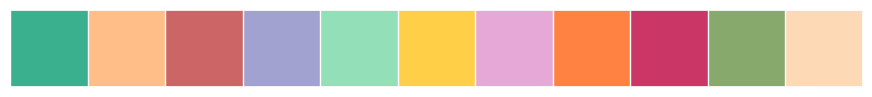

In [11]:
%time
# Названия цветов берём отсюда:
# https://en.wikipedia.org/wiki/List_of_Crayola_crayon_colors
crayon_colors = [
    "Jungle Green",
    "Macaroni and Cheese", # кремово-оранжевый
    
    "Fuzzy Wuzzy",         # коричнево-розовый
    "Blue Bell",           # сиренево-синий
    "Sea Green",           # морской зелёный
    "Sunglow",             # солнечно-жёлтый
    "Orchid",              # орхидея
    "Mango Tango",         
    "Jazzberry Jam",       # малиновый
    "Asparagus",           # спаржевый зелёный
    "Apricot"
]

palette = sns.crayon_palette(crayon_colors)

sns.set_theme(style="darkgrid", palette=palette)
sns.palplot(palette)
plt.show()

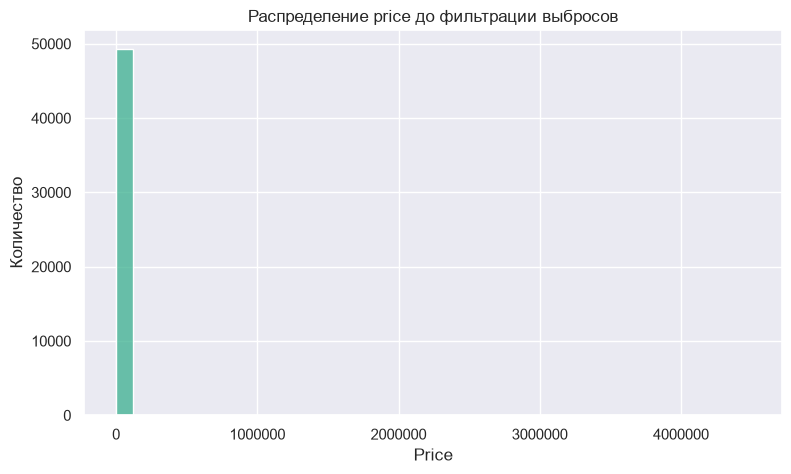

In [12]:
# Строим гистограмму целевой переменной до удаления выбросов.
plt.figure(figsize=(9, 5))
sns.histplot(work_data["price"], bins=38, kde=False)
plt.title("Распределение price до фильтрации выбросов")
plt.xlabel("Price")
plt.ylabel("Количество")
plt.ticklabel_format(style='plain', axis='x')  # отключаем 1e6
plt.show()

Первая гистограмма сильно искажена из-за выбросов. Большая часть цен находится в относительно небольшом диапазоне, а редкие очень дорогие объявления сильно растягивают шкалу. Boxplot помогает визуально увидеть выбросы в цене.

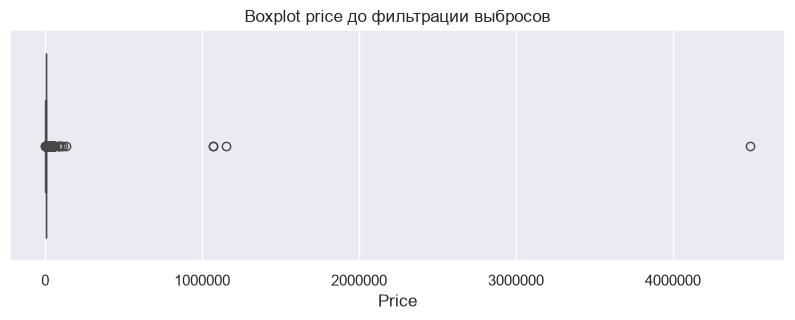

In [13]:
# Boxplot помогает визуально увидеть выбросы в цене.
plt.figure(figsize=(10, 3))
sns.boxplot(x=work_data["price"])
plt.title("Boxplot price до фильтрации выбросов")
plt.xlabel("Price")
plt.ticklabel_format(style='plain', axis='x')  # отключаем 1e6
plt.show()

Boxplot хорошо показывает выбросы. Цены далеко выше верхнего уса могут быть объявлениями премиум-класса, ошибками данных или просто редкими случаями. Такие значения могут сильно влиять на простые модели и графики.  
Посмотрим на числовые значения выбросов:

In [14]:
print(work_data["price"].nlargest(5),'\n')
print(work_data["price"].nsmallest(5))

32611     4490000
12168     1150000
55437     1070000
57803     1070000
123877     135000
Name: price, dtype: int64 

53144      43
87511      45
117339    401
85617     695
102756    695
Name: price, dtype: int64


In [15]:
# Удаляем строки ниже 1-го и выше 99-го перцентиля цены.
lower_price = work_data["price"].quantile(0.01)
upper_price = work_data["price"].quantile(0.99)

filtered_data = work_data[
    work_data["price"].between(lower_price, upper_price)
].copy()

print(f"1-й перцентиль: {lower_price:.2f}")
print(f"99-й перцентиль: {upper_price:.2f}")
print(f"Строк до фильтрации: {len(work_data)}")
print(f"Строк после фильтрации: {len(filtered_data)}")

1-й перцентиль: 1475.00
99-й перцентиль: 13000.00
Строк до фильтрации: 49352
Строк после фильтрации: 48379


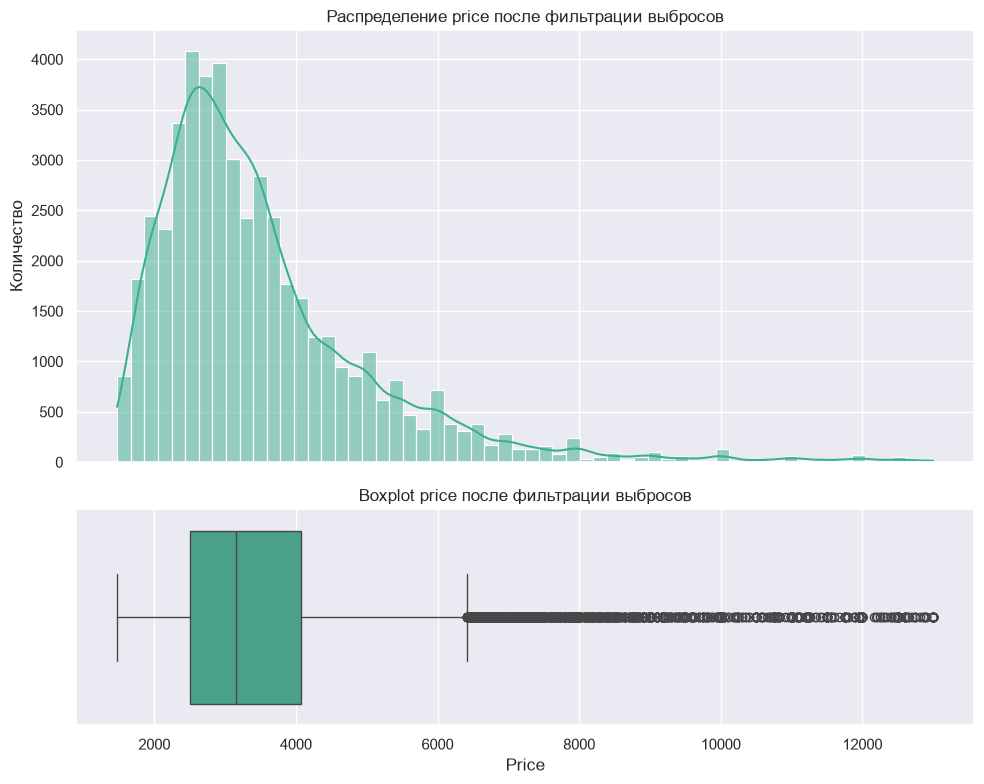

In [16]:
fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(10, 8),
    gridspec_kw={'height_ratios': [2, 1]},  # гистограмма в 2 раза выше
    sharex=True  # общая ось X
)

sns.histplot(filtered_data["price"], 
             bins=60, kde=True, ax=ax1)
ax1.set_title("Распределение price после фильтрации выбросов")
ax1.set_ylabel("Количество")
ax1.ticklabel_format(style='plain', axis='x')

sns.boxplot(x=filtered_data["price"], ax=ax2)
ax2.set_title("Boxplot price после фильтрации выбросов")
ax2.set_xlabel("Price")
ax2.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

После удаления нижнего 1% и верхнего 1% цен распределение становится заметно понятнее. Целевая переменная (price) всё ещё скошена вправо, но экстремальные значения уже не доминируют на графике.

### 3.4 Анализ признаков (характеристик)

#### 3.4.1 Анализ признака interest_level

In [17]:
# Узнаем тип столбца interest_level
filtered_data["interest_level"].dtype

<StringDtype(storage='python', na_value=nan)>

Вот, что значит <StringDtype(storage='python', na_value=nan)>  

столбец "interest_level":  
- содержит текст (строки);  
- хранится через обычные Python-объекты (storage='python');  
- использует nan для пропусков (na_value=nan).

Выведем значения в этом столбце. Посмотрим, колько записей содержит каждое значение.

In [18]:
filtered_data["interest_level"].value_counts()

interest_level
low       33697
medium    11116
high       3566
Name: count, dtype: int64

Кодируем категории числами: low, medium и high превращаются в 0, 1 и 2.  
{"low": 0, "medium": 1, "high": 2}  


Такое кодирование допустимо здесь  
В этом конкретном признаке есть естественный порядок:  
low < medium < high  
Поэтому простое кодирование 0, 1, 2 выглядит логично.  
Для закодированных значений создадим столбец "interest_level_encoded"

In [19]:
# Кодируем категории числами: low, medium и high превращаются в 0, 1 и 2.
interest_level_map = {"low": 0, "medium": 1, "high": 2}
filtered_data["interest_level_encoded"] = filtered_data["interest_level"].map(interest_level_map)
filtered_data.tail()

,bathrooms,bedrooms,interest_level,price,interest_level_encoded
124000,1.0,3,low,2800,0
124002,1.0,2,medium,2395,1
124004,1.0,1,medium,1850,1
124008,1.0,2,medium,4195,1
124009,1.0,3,high,4280,2


Визуализируем распределение признака "interest_level" с использованием параметра hue="interest_level" для раскраски значений по категориям:

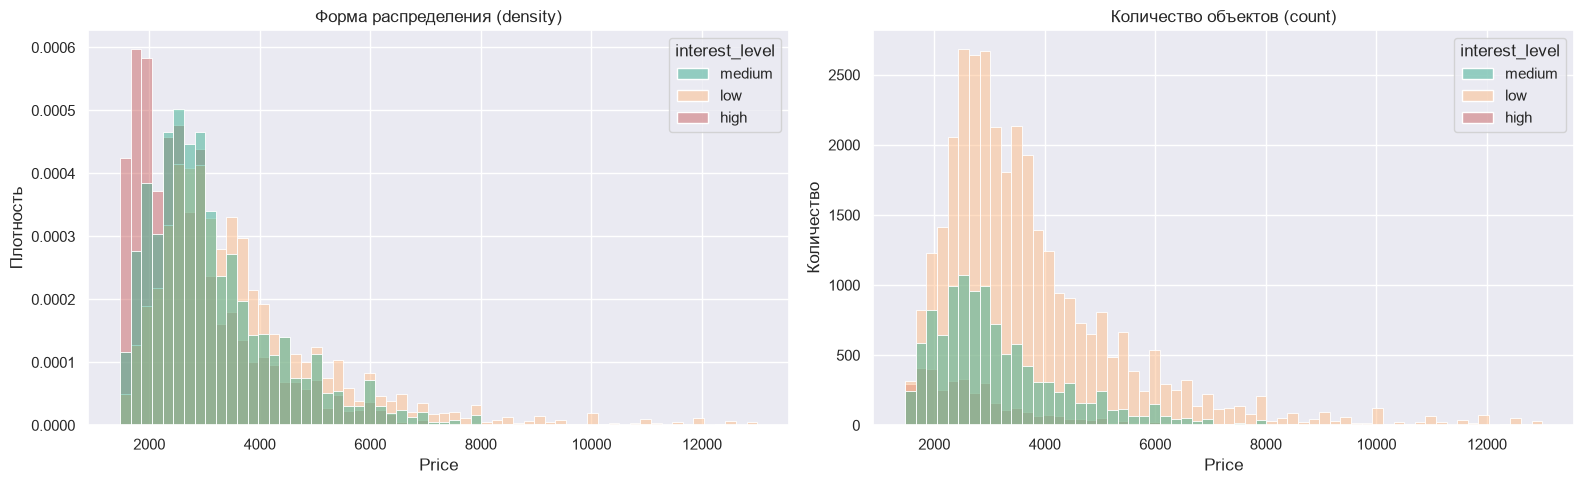

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Левый график: плотность (форма распределения)
sns.histplot(
    data=filtered_data, x="price", hue="interest_level",
    bins=60, kde=False, stat="density", common_norm=False,
    alpha=0.5, ax=ax1
)
ax1.set_title("Форма распределения (density)")
ax1.set_xlabel("Price")
ax1.set_ylabel("Плотность")
ax1.ticklabel_format(style='plain', axis='x')

# Правый график: количество
sns.histplot(
    data=filtered_data, x="price", hue="interest_level",
    bins=60, kde=False, stat="count",
    alpha=0.5, ax=ax2
)
ax2.set_title("Количество объектов (count)")
ax2.set_xlabel("Price")
ax2.set_ylabel("Количество")
ax2.ticklabel_format(style='plain', axis='x')

plt.tight_layout()
plt.show()

Так как количество в разных категориях разное, при построении левого графика использован параметр stat="density" — плотность распределения.  
Это нормированная версия гистограммы, где площадь всех столбиков в сумме равна 1 (или 100%). Это нужно для сравнения формы распределений, а не абсолютных значений.


Мы видим, что высокий интерес вызывают недорогие предложения, хотя их количество невелико по сравнению с low и medium.


### 3.4.2 Анализ признаков bathrooms, bedrooms

Строим гистограммы для количества ванных комнат и спален.

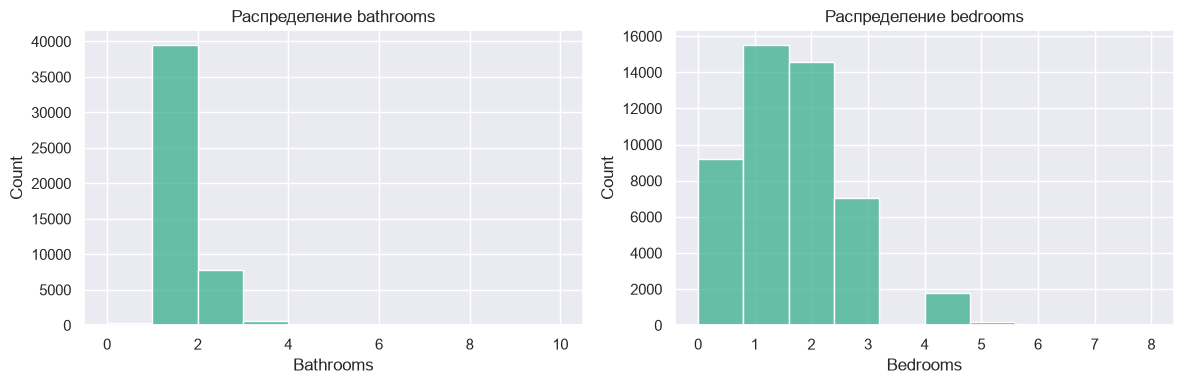

In [21]:
# Строим гистограммы для количества ванных комнат и спален.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(filtered_data["bathrooms"], bins=10, ax=axes[0])
axes[0].set_title("Распределение bathrooms")
axes[0].set_xlabel("Bathrooms")

sns.histplot(filtered_data["bedrooms"], bins=10, ax=axes[1])
axes[1].set_title("Распределение bedrooms")
axes[1].set_xlabel("Bedrooms")

plt.tight_layout()
plt.show()

Визуализируем данные о количестве спален и ванных комнат с помощью диаграмм размаха (т.н. "ящиков с усами")

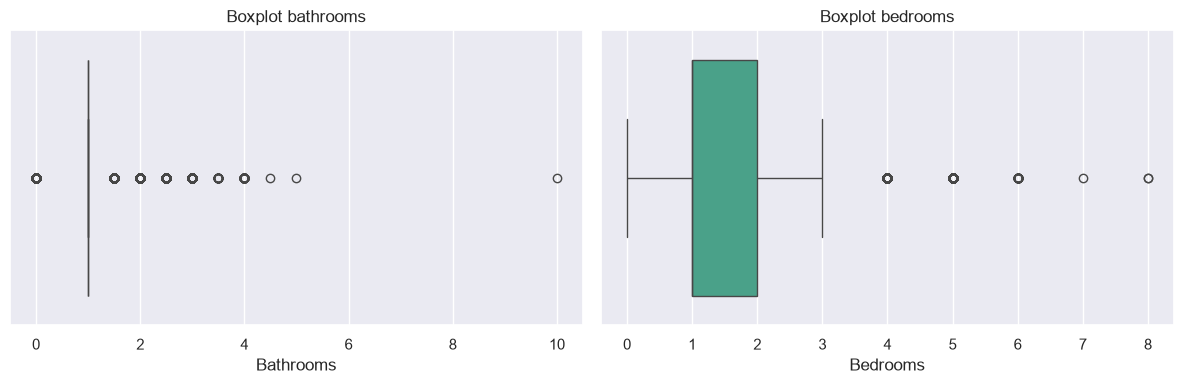

In [22]:
# Проверяем bathrooms и bedrooms через boxplot.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=filtered_data["bathrooms"], ax=axes[0])
axes[0].set_title("Boxplot bathrooms")
axes[0].set_xlabel("Bathrooms")

sns.boxplot(x=filtered_data["bedrooms"], ax=axes[1])
axes[1].set_title("Boxplot bedrooms")
axes[1].set_xlabel("Bedrooms")

plt.tight_layout()
plt.show()

Гистограммы и диаграммы размаха для bathrooms и bedrooms показывают, что большинство объявлений имеет небольшое количество ванных комнат и спален. После основной фильтрации целевой переменной **критичных выбросов для этих двух признаков нет**.

### 3.5 Комплексный анализ

### 3.5.1 Корреляционная матрица и её тепловая карта

Построим и визуализируем корреляционную матрицу. Исключим и сами границы 1-го и 99-го перцентилей, используя .between(..., inclusive="neither")

In [23]:
# Формируем корреляционную матрицу для базовых признаков и цены.
# correlation_data = filtered_data[
#     (filtered_data["price"] > lower_price)
#     & (filtered_data["price"] < upper_price)
# ].copy() # исключаем сами границы 1-го и 99-го перцентилей

correlation_data = filtered_data[
    filtered_data["price"].between(lower_price, upper_price, inclusive="neither")
].copy()



correlation_data = correlation_data[
    ["bathrooms", "bedrooms", "interest_level_encoded", "price"]
].rename(columns={"interest_level_encoded": "interest"})

corr_matrix = correlation_data.corr()
corr_matrix

,bathrooms,bedrooms,interest,price
bathrooms,1.000000,0.517200,-0.062819,0.670808
bedrooms,0.517200,1.000000,0.051282,0.547310
interest,-0.062819,0.051282,1.000000,-0.199652
price,0.670808,0.547310,-0.199652,1.000000


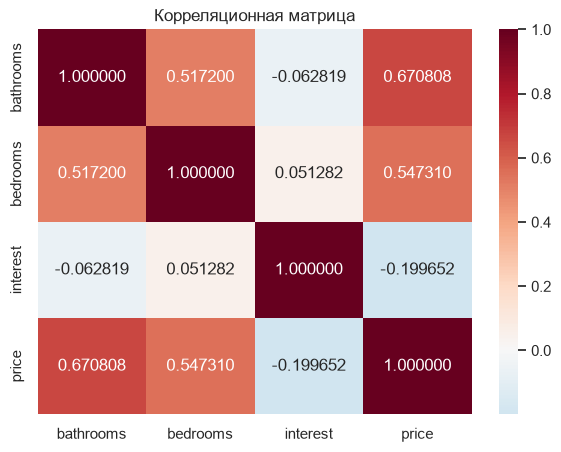

In [24]:
# Визуализируем корреляции с помощью heatmap.
plt.figure(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, cmap="RdBu_r", center=0, fmt=".6f")
cmaps = ["coolwarm", "RdBu_r", "viridis", "plasma", "magma", "Blues", "RdYlGn", "PiYG"]
plt.title("Корреляционная матрица")
plt.show()

Лучше всего цена коррелирует с выееыми комнатами (коэффициент корреляции 0,670808).

#### Краткий анализ границ диапазона для оценки корреляций

In [25]:
# Считаем количество значений, строго равных нижней границе
lower_count = (filtered_data["price"] == lower_price).sum()

# Считаем количество значений, строго равных верхней границе
upper_count = (filtered_data["price"] == upper_price).sum()

print(f"Значений ровно на нижней границе ({lower_price}): {lower_count}")
print(f"Значений ровно на верхней границе ({upper_price}): {upper_count}")
print(f"Всего на границах: {lower_count + upper_count} из {len(filtered_data)}")

Значений ровно на нижней границе (1475.0): 15
Значений ровно на верхней границе (13000.0): 21
Всего на границах: 36 из 48379


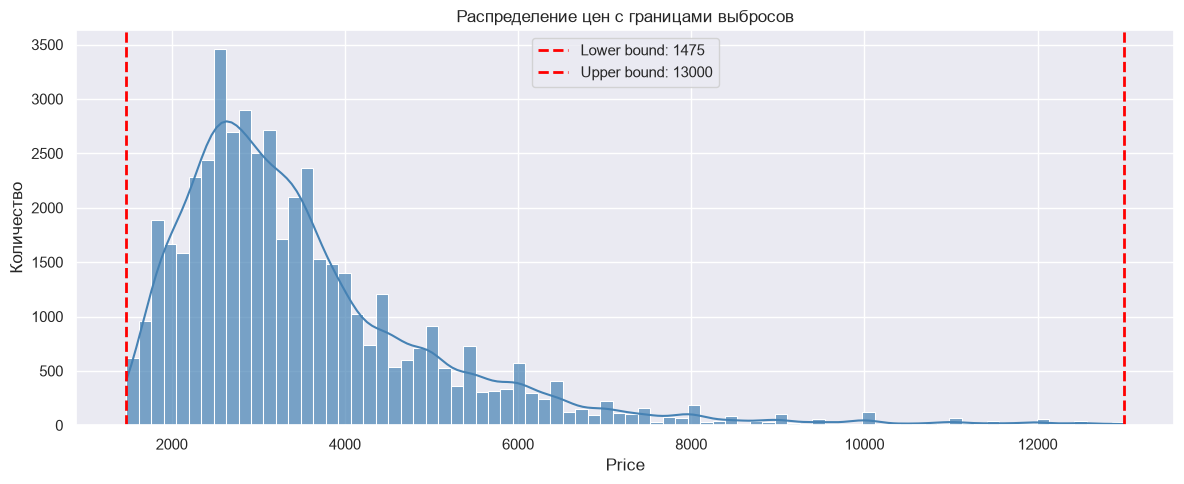

In [26]:
plt.figure(figsize=(12, 5))

sns.histplot(data=filtered_data, x="price", bins=80, kde=True, color="steelblue", alpha=0.7)

# Добавляем вертикальные линии для границ
plt.axvline(lower_price, color="red", linestyle="--", linewidth=2, label=f"Lower bound: {lower_price:.0f}")
plt.axvline(upper_price, color="red", linestyle="--", linewidth=2, label=f"Upper bound: {upper_price:.0f}")

plt.title("Распределение цен с границами выбросов")
plt.xlabel("Price")
plt.ylabel("Количество")
plt.ticklabel_format(style='plain', axis='x')
plt.legend()
plt.tight_layout()
plt.show()

### 3.5.2 Визуализация корреляции между признаками и target. Диаграмма рассеяния (scatterplot)

На диаграмме рассеяния каждому наблюдению (или элементарной единице набора данных) соответствует точка, координаты которой равны значениям двух каких-то параметров этого наблюдения. Диаграммы рассеяния используются для демонстрации наличия или отсутствия корреляции между двумя переменными. Добавим отображение категориального признака interest_level для повышения информативности.

CPU times: total: 0 ns
Wall time: 5.25 μs


Text(0.5, 1.0, 'количество комнат и цена')

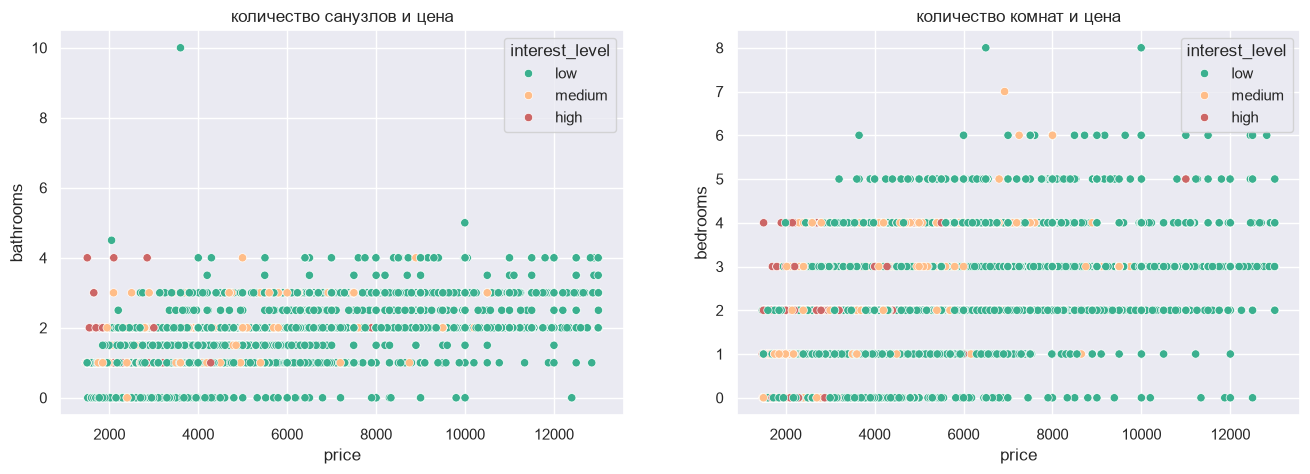

In [36]:
%time
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
ho=["low", "medium", "high"]
sns.scatterplot(data=filtered_data, x="price", y="bathrooms", ax=ax1, 
                hue="interest_level", hue_order=ho)
sns.scatterplot(data=filtered_data, x="price", y="bedrooms", ax=ax2, 
                hue="interest_level",hue_order=ho)
ax1.set_title("количество санузлов и цена")
ax2.set_title("количество комнат и цена")

Явные корреляции на диаграммах малозаменты.

In [30]:
filtered_data.sample(n=8, random_state=rs)

,bathrooms,bedrooms,interest_level,price,interest_level_encoded
3230,1.0,2,medium,2850,1
94946,1.0,0,low,2400,0
75895,1.0,0,low,2550,0
33174,1.0,1,medium,2400,1
123977,1.0,1,low,3795,0
26031,1.0,2,medium,1975,1
38626,1.0,0,high,1650,2
116642,1.0,1,low,4050,0


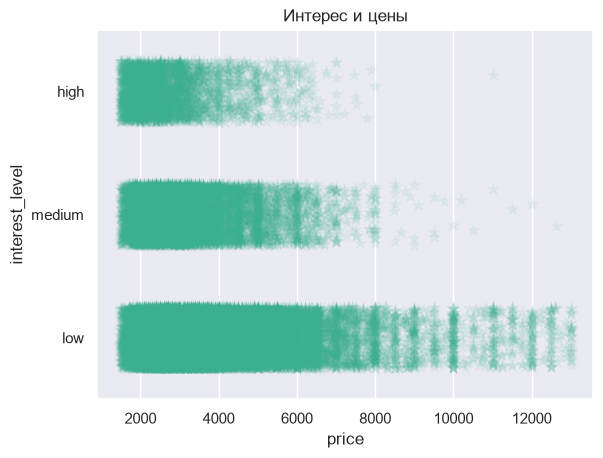

In [40]:
sns.stripplot(data=filtered_data,
              y="interest_level",
              x="price",
              order=["high", "medium", "low"],
              alpha=0.1, size=10, jitter=0.25, marker='*'
             )
plt.title("Интерес и цены");